In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

all_data = []

for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.p["class"][1]
        availability = book.find("p", class_="instock availability").text.strip()

        all_data.append([title, price, rating, availability])

df = pd.DataFrame(all_data, columns=["Title", "Price", "Rating", "Availability"])

df.to_csv("raw_books_data.csv", index=False)

print("Data downloaded successfully!")

Data downloaded successfully!


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   object
 3   Availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [ ]:
##DATA CLEANNG AND PREPROCESSING

In [9]:
import pandas as pd

df = pd.read_csv("raw_books_data.csv")
df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [10]:
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   object
 3   Availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


Title           0
Price           0
Rating          0
Availability    0
dtype: int64

In [2]:
import pandas as pd

df = pd.read_csv("raw_books_data.csv")

In [3]:
df['Price'].head(10)

0    Â£51.77
1    Â£53.74
2    Â£50.10
3    Â£47.82
4    Â£54.23
5    Â£22.65
6    Â£33.34
7    Â£17.93
8    Â£22.60
9    Â£52.15
Name: Price, dtype: object

In [4]:
df['Price'] = df['Price'].str.extract('(\d+\.\d+)')
df['Price'] = df['Price'].astype(float)

In [5]:
df['Price'].head()

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   object 
 3   Availability  1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 31.4+ KB


In [7]:
df['Price'].isnull().sum()

np.int64(0)

In [10]:
df['Price'] = df['Price'].astype(str)

In [11]:
df['Price'].str.replace('£','')

0      51.77
1      53.74
2       50.1
3      47.82
4      54.23
       ...  
995    55.53
996    57.06
997    16.97
998    53.98
999    26.08
Name: Price, Length: 1000, dtype: object

In [12]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('£','')
df['Price'] = df['Price'].astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   object 
 3   Availability  1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 31.4+ KB


In [14]:
rating_map = {
    'One':1,
    'Two':2,
    'Three':3,
    'Four':4,
    'Five':5
}

df['Rating'] = df['Rating'].map(rating_map)

In [15]:
df['Availability'] = df['Availability'].apply(lambda x: 1 if "In stock" in x else 0)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df['Price_Category'] = pd.cut(df['Price'],
                               bins=[0,20,40,100],
                               labels=['Low','Medium','High'])

In [18]:
df['High_Rating'] = df['Rating'].apply(lambda x: 1 if x >=4 else 0)

In [19]:
df.to_csv("clean_books_data.csv", index=False)

In [21]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df)

                                                 Title  Price  Rating  \
0                                 A Light in the Attic  51.77       3   
1                                   Tipping the Velvet  53.74       1   
2                                           Soumission  50.10       1   
3                                        Sharp Objects  47.82       4   
4                Sapiens: A Brief History of Humankind  54.23       5   
5                                      The Requiem Red  22.65       1   
6    The Dirty Little Secrets of Getting Your Dream...  33.34       4   
7    The Coming Woman: A Novel Based on the Life of...  17.93       3   
8    The Boys in the Boat: Nine Americans and Their...  22.60       4   
9                                      The Black Maria  52.15       1   
10      Starving Hearts (Triangular Trade Trilogy, #1)  13.99       2   
11                               Shakespeare's Sonnets  20.66       4   
12                                         Set Me F

In [23]:
###----PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
import pandas as pd

df = pd.read_csv("clean_books_data.csv")
df.head()

,Title,Price,Rating,Availability,Price_Category,High_Rating
0,A Light in the Attic,51.77,3,1,High,0
1,Tipping the Velvet,53.74,1,1,High,0
2,Soumission,50.10,1,1,High,0
3,Sharp Objects,47.82,4,1,High,1
4,Sapiens: A Brief History of Humankind,54.23,5,1,High,1


In [24]:
df.describe()

,Price,Rating,Availability,High_Rating
count,1000.00000,1000.000000,1000.0,1000.000000
mean,35.07035,2.923000,1.0,0.375000
std,14.44669,1.434967,0.0,0.484365
min,10.00000,1.000000,1.0,0.000000
25%,22.10750,2.000000,1.0,0.000000
50%,35.98000,3.000000,1.0,0.000000
75%,47.45750,4.000000,1.0,1.000000
max,59.99000,5.000000,1.0,1.000000


In [25]:
df['Rating'].value_counts()

Rating
1    226
3    203
5    196
2    196
4    179
Name: count, dtype: int64

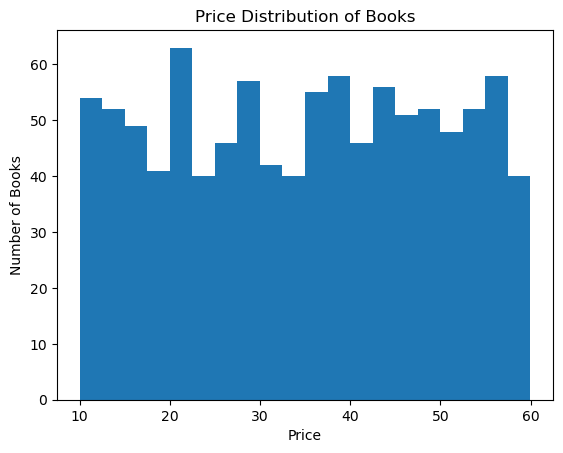

In [26]:
##---Price Distribution (Histogram)
import matplotlib.pyplot as plt

plt.hist(df['Price'], bins=20)
plt.title("Price Distribution of Books")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.show()

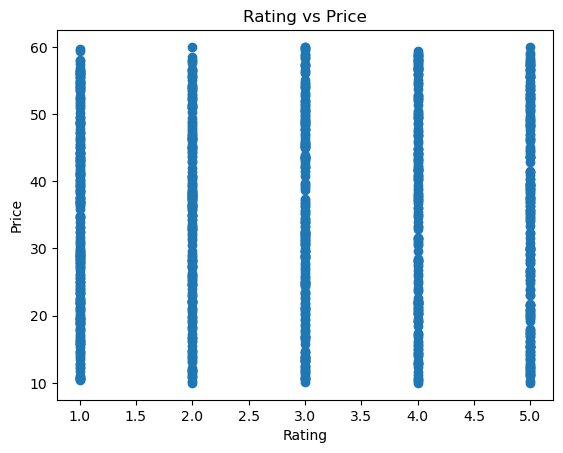

In [27]:
###----Rating vs Price Relationship
plt.scatter(df['Rating'], df['Price'])
plt.title("Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

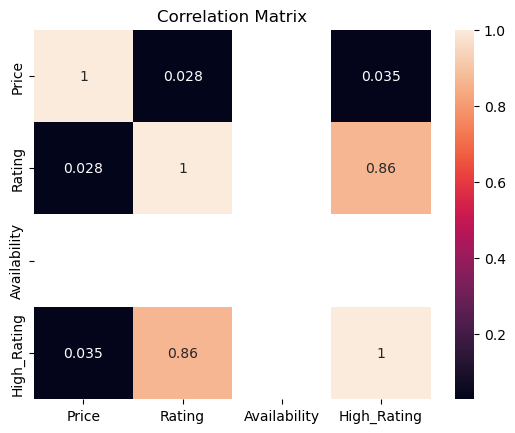

In [29]:
##---Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()


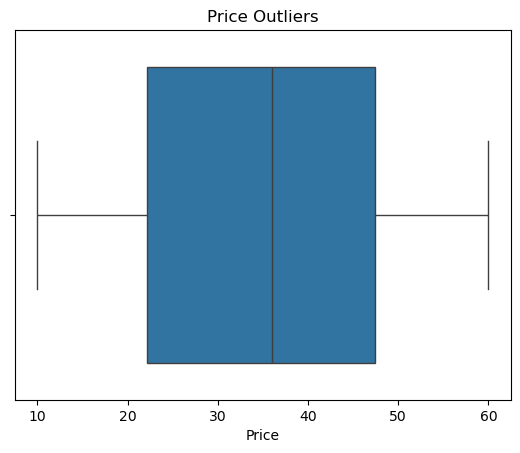

In [30]:
###----Boxplot (Detect Outliers)
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [31]:
####--- phase 4: MODEL BUILDING & EVALUATION
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
df = pd.read_csv("clean_books_data.csv")
df.head()

,Title,Price,Rating,Availability,Price_Category,High_Rating
0,A Light in the Attic,51.77,3,1,High,0
1,Tipping the Velvet,53.74,1,1,High,0
2,Soumission,50.10,1,1,High,0
3,Sharp Objects,47.82,4,1,High,1
4,Sapiens: A Brief History of Humankind,54.23,5,1,High,1


In [33]:
###---Create Target Variable
df['High_Rating'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

In [34]:
X = df[['Price']]
y = df['High_Rating']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.505


In [39]:
print(confusion_matrix(y_test, y_pred))

[[69 51]
 [48 32]]


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.57      0.58       120
           1       0.39      0.40      0.39        80

    accuracy                           0.51       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.51      0.51      0.51       200



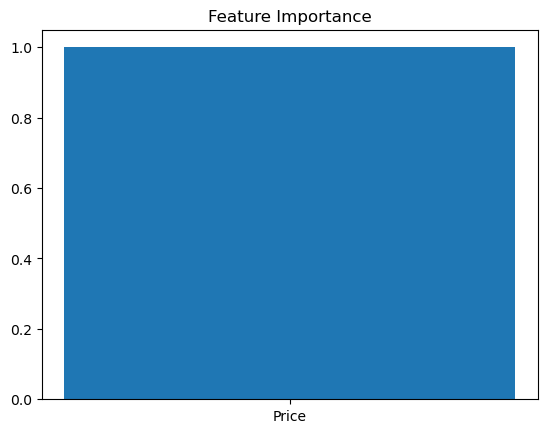

In [41]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(['Price'], importance)
plt.title("Feature Importance")
plt.show()

In [2]:
import os
os.getcwd()

'C:\\Users\\tripa'

In [3]:
os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.gologin',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.spyder-py3',
 '.vscode',
 'anaconda3',
 'AppData',
 'Application Data',
 'clean_books_data.csv',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Ecommerce_Capstone_Project.ipynb',
 'Favorites',
 'Financial_Risk_Analysis_Morgan_Stanley.ipynb',
 'Links',
 'Local Settings',
 'mansi tripathi',
 'ML Project.ipynb',
 'Music',
 'My Documents',
 'NetHood',
 'New folder',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{10b8d925-2f04-11f0-9674-bb44e9265e3c}.TM.blf',
 'NTUSER.DAT{10b8d925-2f04-11f0-9674-bb44e9265e3c}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{10b8d925-2f04-11f0-9674-bb44e9265e3c}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'raw_books_data.csv',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Videos',
 'walmart retentio